# Indirect Methods for Optimal Control

We now introduce an explicit dynamical system:

$$
\dot{x}(t) = f(x(t), u(t), t).
$$

Unlike the previous notebook, the state trajectory $x(t)$ can no longer be chosen arbitrarily. It must be generated by the control $u(t)$ through the system dynamics.

The **goal** of this notebook is to understand how necessary conditions for optimality can be derived and used to solve an optimal control problem.

## 1. Minimum-Effort Control

### Requirement

Move the system from

$$
p(0)=0,\qquad v(0)=0
$$

to

$$
p(T)=1,\qquad v(T)=0
$$

while minimizing control effort.

### State

$$
x =
\begin{bmatrix}
p\\
v
\end{bmatrix}
$$

### Control

$$
u = a
$$

### Dynamics

$$
\dot{x}=
f(x,u)=
\begin{bmatrix}
v\\
u
\end{bmatrix}.
$$

### Objective

$$
J[u]=
\frac12
\int_0^T u(t)^2\,dt.
$$

### Boundary conditions

$$
x(0)=
\begin{bmatrix}
0\\
0
\end{bmatrix},
\qquad
x(T)=
\begin{bmatrix}
1\\
0
\end{bmatrix}.
$$

### Implementation

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)


#### Dynamics

In [2]:
def dynamics(x,u):
    position, velocity = x
    return jnp.array([velocity, u])    

#### Running Cost or Stage Cost

In [4]:
def running_cost(x,u):
    return 0.5 * u**2

#### Costate and Hamiltonian

The state and control cannot be chosen independently because they must satisfy

$$
\dot{x} = f(x,u).
$$

This can be viewed as a time-dependent equality constraint:

$$
f(x,u) - \dot{x} = 0.
$$

As in constrained optimization, introduce a Lagrange multiplier.  
Because the constraint exists at every time $t$, the multiplier is now a function of time:

$$
\lambda(t).
$$

This variable is called the **costate**.

The Hamiltonian is defined as

$$
H(x,u,\lambda)
=L(x,u)
+
\lambda^\top f(x,u).
$$

In [9]:
def hamiltonian(x, u, costate):
    return (
        running_cost(x,u) + 
        costate @ dynamics(x,u)
    )

In [10]:
hamiltonian_grad_x = jax.grad(hamiltonian, argnums=0)
hamiltonian_grad_u = jax.grad(hamiltonian, argnums=1)
hamiltonian_grad_costate = jax.grad(hamiltonian,argnums=2)

In [11]:
x_test = jnp.array([0.5, 0.2])
u_test = 0.3
costate_test = jnp.array([1.0, -0.4])

print(
    "dH/dx:",
    hamiltonian_grad_x(
        x_test,
        u_test,
        costate_test,
    ),
)

print(
    "dH/du:",
    hamiltonian_grad_u(
        x_test,
        u_test,
        costate_test,
    ),
)

print(
    "dH/dlambda:",
    hamiltonian_grad_costate(
        x_test,
        u_test,
        costate_test,
    ),
)

dH/dx: [0. 1.]
dH/du: -0.10000000000000003
dH/dlambda: [0.2 0.3]


#### Takeaway

The system dynamics act as equality constraints on the trajectory.

Introducing a time-varying Lagrange multiplier produces the **costate** $\lambda(t)$, and the Hamiltonian

$$
H=L+\lambda^\top f
$$

combines the objective and dynamics.

The indirect optimality conditions give:

$$
\dot{x}=\frac{\partial H}{\partial\lambda},
$$

$$
\dot{\lambda}=-\frac{\partial H}{\partial x},
$$

$$
\frac{\partial H}{\partial u}=0.
$$

For the double integrator,

$$
u^\star=-\lambda_v.
$$

#### Solving the State–Costate Equations

For the double integrator, the necessary conditions gave

$$
\dot p = v,
$$

$$
\dot v = u,
$$

$$
\dot{\lambda}_p = 0,
$$

$$
\dot{\lambda}_v = -\lambda_p,
$$

and

$$
u^\star = -\lambda_v.
$$

The initial state is known at \(t=0\),

$$
p(0)=0,
\qquad
v(0)=0,
$$

while the terminal state must satisfy

$$
p(T)=1,
\qquad
v(T)=0.
$$

The state and costate equations therefore form a two-point boundary-value problem.

In [12]:
T = 5.0

t = jnp.linspace(0.0, T, 200)


def optimal_control(t, T):
    return 6.0 / T**2 - 12.0 * t / T**3


def optimal_velocity(t, T):
    return (
        6.0 * t / T**2
        - 6.0 * t**2 / T**3
    )


def optimal_position(t, T):
    return (
        3.0 * t**2 / T**2
        - 2.0 * t**3 / T**3
    )


u_star = optimal_control(t, T)
v_star = optimal_velocity(t, T)
p_star = optimal_position(t, T)

In [13]:
print("p(0):", p_star[0])
print("v(0):", v_star[0])

print("p(T):", p_star[-1])
print("v(T):", v_star[-1])

p(0): 0.0
v(0): 0.0
p(T): 1.0
v(T): 0.0


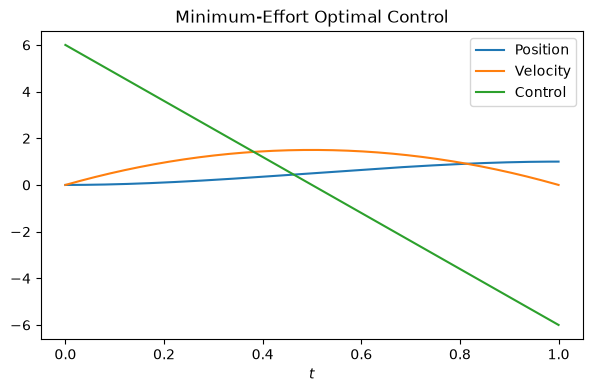

In [14]:
plt.figure(figsize=(7, 4))

plt.plot(t, p_star, label="Position")
plt.plot(t, v_star, label="Velocity")
plt.plot(t, u_star, label="Control")

plt.xlabel("$t$")
plt.title("Minimum-Effort Optimal Control")
plt.legend()
plt.show()

### Pontryagin's Minimum Principle — Bounded Controls

So far, the control was unconstrained.

For an unconstrained optimum, we used

$$
\frac{\partial H}{\partial u}=0.
$$

Real systems usually have actuator limits. For example,

$$
u_{\min} \leq u(t) \leq u_{\max}.
$$

Pontryagin's Minimum Principle requires the optimal control to minimize
the Hamiltonian over the admissible control set:

$$
u^\star(t)=
\arg\min_{u\in U}
$$

The state and costate equations remain

$$
\dot{x}^\star=
\frac{\partial H}{\partial \lambda},
$$

$$
\dot{\lambda}^\star=
-\frac{\partial H}{\partial x}.
$$

In [15]:
def optimal_control_from_costate(costate, u_min=-2.0, u_max=2.0):
    lambda_v = costate[1]

    u_free = -lambda_v

    return jnp.clip(
        u_free,
        u_min,
        u_max,
    )

In [16]:
costate_values = jnp.array([
    [0.0, -4.0],
    [0.0, -1.0],
    [0.0,  0.5],
    [0.0,  3.0],
])

for costate in costate_values:
    lambda_v = costate[1]

    u_free = -lambda_v
    u_bounded = optimal_control_from_costate(costate)

    print(
        f"lambda_v={lambda_v:5.2f} | "
        f"u_free={u_free:5.2f} | "
        f"u_bounded={u_bounded:5.2f}"
    )

lambda_v=-4.00 | u_free= 4.00 | u_bounded= 2.00
lambda_v=-1.00 | u_free= 1.00 | u_bounded= 1.00
lambda_v= 0.50 | u_free=-0.50 | u_bounded=-0.50
lambda_v= 3.00 | u_free=-3.00 | u_bounded=-2.00


## Numerical Solution: Indirect Shooting

The indirect method produces state and costate differential equations, but the
initial costate is unknown.

For the double integrator,

$$
x(0)
$$

is known, but

$$
\lambda(0)
$$

must be chosen such that the integrated trajectory satisfies the terminal
boundary condition

$$
x(T)=x_f.
$$

The shooting method therefore treats the initial costate as an unknown parameter:

$$
\lambda_0
\rightarrow
\text{integrate state-costate dynamics}
\rightarrow
x(T)
\rightarrow
x(T)-x_f.
$$

The correct initial costate makes the terminal error zero.

In [17]:
U_MIN = -5.0
U_MAX = 5.0


def state_costate_dynamics(y):
    p, v, lambda_p, lambda_v = y

    u = jnp.clip(
        -lambda_v,
        U_MIN,
        U_MAX,
    )

    return jnp.array([
        v,          # p_dot
        u,          # v_dot
        0.0,        # lambda_p_dot
        -lambda_p,  # lambda_v_dot
    ])

In [18]:
def rk4_step(y, dt):
    k1 = state_costate_dynamics(y)
    k2 = state_costate_dynamics(y + 0.5 * dt * k1)
    k3 = state_costate_dynamics(y + 0.5 * dt * k2)
    k4 = state_costate_dynamics(y + dt * k3)

    return y + (dt / 6.0) * (
        k1 + 2.0 * k2 + 2.0 * k3 + k4
    )

In [19]:
T = 1.0
N = 200
dt = T / N

x_initial = jnp.array([0.0, 0.0])
x_target = jnp.array([1.0, 0.0])

In [20]:
def rollout(lambda0):
    y = jnp.concatenate([
        x_initial,
        lambda0,
    ])

    trajectory = [y]

    for _ in range(N):
        y = rk4_step(y, dt)
        trajectory.append(y)

    return jnp.stack(trajectory)

In [21]:
lambda0_guess = jnp.array([-8.0, -4.0])

trajectory = rollout(lambda0_guess)

print("Final state:", trajectory[-1, :2])
print("Target:", x_target)

Final state: [ 6.66666667e-01 -2.32106001e-15]
Target: [1. 0.]


In [22]:
def terminal_error(lambda0):
    trajectory = rollout(lambda0)

    x_final = trajectory[-1, :2]

    return x_final - x_target

In [23]:
terminal_error_jacobian = jax.jacfwd(terminal_error)

In [24]:
def shooting_method(lambda0, num_iterations=10):
    lambda_guess = lambda0

    for _ in range(num_iterations):
        error = terminal_error(lambda_guess)

        jacobian = terminal_error_jacobian(
            lambda_guess
        )

        correction = jnp.linalg.solve(
            jacobian,
            error,
        )

        lambda_guess = lambda_guess - correction

    return lambda_guess

In [25]:
lambda0_star = shooting_method(
    lambda0=jnp.array([-10.0, -5.0]),
    num_iterations=10,
)

print("Optimal initial costate:", lambda0_star)
print("Terminal error:", terminal_error(lambda0_star))

Optimal initial costate: [-12.90975468  -6.45487734]
Terminal error: [8.8817842e-16 1.3669621e-15]


In [26]:
trajectory_star = rollout(lambda0_star)

position = trajectory_star[:, 0]
velocity = trajectory_star[:, 1]
lambda_v = trajectory_star[:, 3]

control = jnp.clip(
    -lambda_v,
    U_MIN,
    U_MAX,
)

time = jnp.linspace(0.0, T, N + 1)

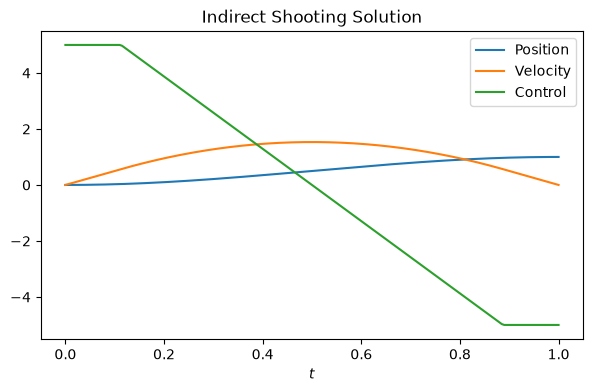

In [27]:
plt.figure(figsize=(7, 4))

plt.plot(time, position, label="Position")
plt.plot(time, velocity, label="Velocity")
plt.plot(time, control, label="Control")

plt.xlabel("$t$")
plt.title("Indirect Shooting Solution")
plt.legend()
plt.show()

### Takeaway

Indirect shooting does not solve for the control trajectory directly.

Instead:

$$
\lambda(0)
\rightarrow
\lambda(t)
\rightarrow
u^\star(t)
\rightarrow
x(t).
$$

The unknown initial costate is adjusted until the integrated trajectory satisfies
the terminal boundary conditions.

Thus an indirect optimal-control problem can be solved numerically even when
the integration constants cannot be obtained analytically.

For bounded controls, Pontryagin's Minimum Principle determines the admissible
control at each time by minimizing the Hamiltonian over the control set.